In [41]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import numpy as np

In [42]:
col_names = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes",
    "land","wrong_fragment","urgent","hot","num_failed_logins","logged_in",
    "num_compromised","root_shell","su_attempted","num_root","num_file_creations",
    "num_shells","num_access_files","num_outbound_cmds","is_host_login","is_guest_login",
    "count","srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate",
    "same_srv_rate","diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate","label","difficulty"
]

#loading the NSL-KDD dataset to a pandas dataframe
df=pd.read_csv("..\data\\nsl-kdd\KDDTest-21.txt",names=col_names)

In [43]:
df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,13,tcp,telnet,SF,118,2425,0,0,0,0,...,0.38,0.12,0.04,0.0,0.00,0.00,0.12,0.3,guess_passwd,2
1,0,udp,private,SF,44,0,0,0,0,0,...,1.00,0.01,0.01,0.0,0.00,0.00,0.00,0.0,snmpguess,12
2,0,tcp,telnet,S3,0,44,0,0,0,0,...,0.31,0.61,0.00,0.0,0.21,0.68,0.60,0.0,processtable,18
3,0,udp,private,SF,53,55,0,0,0,0,...,1.00,0.00,0.87,0.0,0.00,0.00,0.00,0.0,normal,17
4,0,tcp,private,SH,0,0,0,0,0,0,...,0.06,1.00,1.00,0.0,1.00,1.00,0.00,0.0,nmap,17


In [44]:
df.tail()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
11845,0,udp,domain_u,SF,43,43,0,0,0,0,...,1.00,0.00,0.01,0.00,0.00,0.00,0.00,0.00,normal,18
11846,0,tcp,http,SF,336,285,0,0,0,0,...,0.92,0.02,0.00,0.00,0.00,0.00,0.05,0.00,normal,18
11847,1,tcp,telnet,RSTO,0,15,0,0,0,0,...,0.37,0.03,0.01,0.02,0.05,0.08,0.85,0.58,mscan,13
11848,0,tcp,sunrpc,REJ,0,0,0,0,0,0,...,0.19,0.03,0.01,0.04,0.00,0.00,0.88,1.00,mscan,15
11849,0,udp,private,SF,41,0,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,snmpguess,17


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11850 entries, 0 to 11849
Data columns (total 43 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   duration                     11850 non-null  int64  
 1   protocol_type                11850 non-null  object 
 2   service                      11850 non-null  object 
 3   flag                         11850 non-null  object 
 4   src_bytes                    11850 non-null  int64  
 5   dst_bytes                    11850 non-null  int64  
 6   land                         11850 non-null  int64  
 7   wrong_fragment               11850 non-null  int64  
 8   urgent                       11850 non-null  int64  
 9   hot                          11850 non-null  int64  
 10  num_failed_logins            11850 non-null  int64  
 11  logged_in                    11850 non-null  int64  
 12  num_compromised              11850 non-null  int64  
 13  root_shell      

In [46]:
#check for missing values
df.isnull().sum()

duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate                  0
diff_srv_rate                  0
srv_diff_h

In [47]:
print("Total missing values:",df.isnull().sum().sum())
df=df.dropna()

Total missing values: 0


In [48]:
#statistical measures of the dataset
df.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,difficulty
count,11850.000000,1.185000e+04,1.185000e+04,11850.000000,11850.000000,11850.000000,11850.000000,11850.000000,11850.000000,11850.000000,...,11850.000000,11850.000000,11850.000000,11850.000000,11850.000000,11850.000000,11850.000000,11850.000000,11850.000000,11850.000000
mean,415.439831,1.945644e+04,1.228105e+03,0.000591,0.016034,0.001350,0.190211,0.041181,0.253080,0.227679,...,117.541603,0.539597,0.148986,0.206493,0.024465,0.104181,0.106697,0.263952,0.252209,15.326835
std,1919.441623,6.519865e+05,2.389603e+04,0.024299,0.196379,0.050299,1.222392,0.205401,0.434795,10.025774,...,106.563438,0.423370,0.288758,0.379193,0.114234,0.265086,0.278549,0.377337,0.403039,4.407479
min,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,12.000000,0.070000,0.010000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000
50%,0.000000,2.800000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,83.000000,0.530000,0.020000,0.000000,0.000000,0.000000,0.000000,0.020000,0.000000,17.000000
75%,1.000000,1.600000e+02,9.300000e+01,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,250.000000,1.000000,0.070000,0.090000,0.000000,0.010000,0.000000,0.560000,0.520000,18.000000
max,57715.000000,6.282565e+07,1.288652e+06,1.000000,3.000000,3.000000,101.000000,4.000000,1.000000,796.000000,...,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,20.000000


In [49]:
#checking the number of rows and columns
print("Before removing duplicates:", df.shape)
df = df.drop_duplicates()
print("After removing duplicates:", df.shape)

Before removing duplicates: (11850, 43)
After removing duplicates: (11850, 43)


In [50]:
df=pd.get_dummies(df,columns=["protocol_type","service","flag"])

In [51]:
scaler=MinMaxScaler()
num_cols=df.drop(["label","difficulty"],axis=1).columns
df[num_cols]=scaler.fit_transform(df[num_cols])

In [52]:
df["label"]=df["label"].apply(lambda x: 0 if x=="normal" else 1)

In [53]:
df.head()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,0.000225,1.878214e-06,0.001882,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.000000,7.003509e-07,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.000000,0.000000e+00,0.000034,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.000000,8.436045e-07,0.000043,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


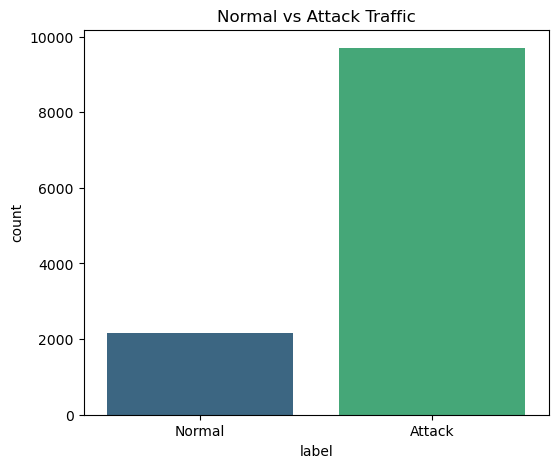

In [54]:
plt.figure(figsize=(6,5))
sns.countplot(x="label",data=df, palette="viridis")
plt.title("Normal vs Attack Traffic")
plt.xticks([0,1],["Normal","Attack"])
plt.show()

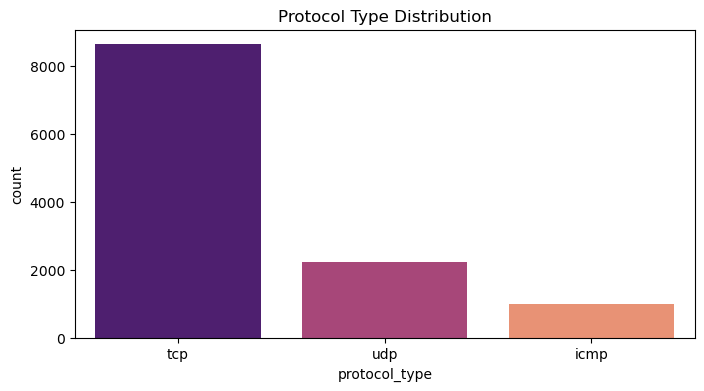

In [55]:
plt.figure(figsize=(8,4))
df_protocol=pd.read_csv("..\data\\nsl-kdd\KDDTest-21.txt",names=col_names)["protocol_type"]
sns.countplot(x=df_protocol, order=df_protocol.value_counts().index, palette="magma")
plt.title("Protocol Type Distribution")
plt.show()

Text(0.5, 1.0, 'top 10 service types')

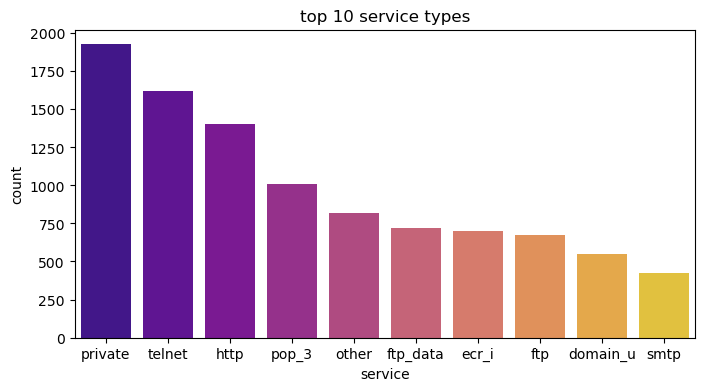

In [56]:
plt.figure(figsize=(8,4))
df_service=pd.read_csv("..\data\\nsl-kdd\KDDTest-21.txt",names=col_names)["service"]
sns.countplot(x=df_service, order=df_service.value_counts().iloc[:10].index, palette='plasma')
plt.title("top 10 service types")

Text(0.5, 1.0, 'Flag Distribution')

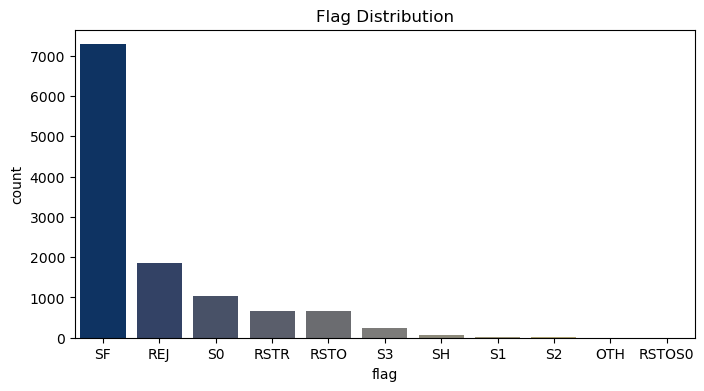

In [57]:
plt.figure(figsize=(8,4))
df_flag=pd.read_csv("..\data\\nsl-kdd\KDDTest-21.txt",names=col_names)["flag"]
sns.countplot(x=df_flag, order=df_flag.value_counts().index, palette='cividis')
plt.title("Flag Distribution")

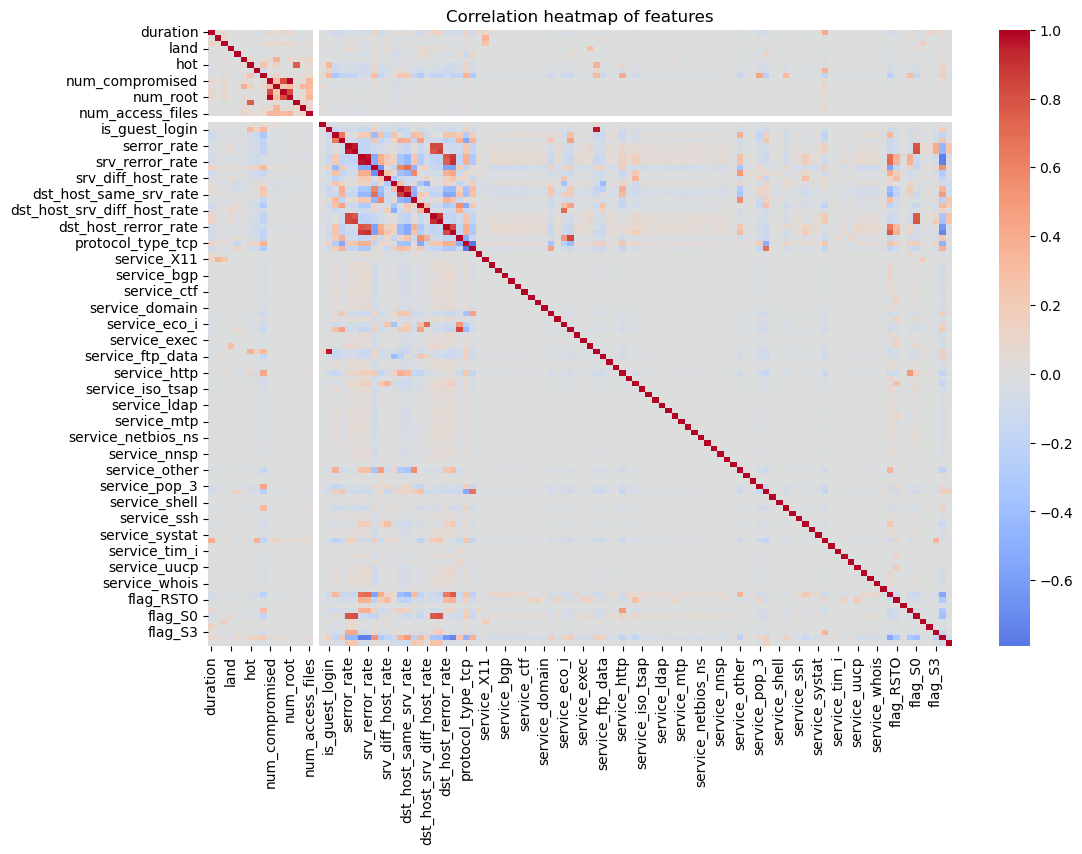

In [58]:
plt.figure(figsize=(12,8))
corr=df[num_cols].corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation heatmap of features")
plt.show()

In [59]:
x=df.drop(["label","difficulty"],axis=1)
y=df["label"]

In [60]:
x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=0.2,random_state=42, stratify=y)

In [61]:
print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (9480, 114)
Test shape: (2370, 114)


In [62]:
scaler = StandardScaler()
X_train = scaler.fit_transform(x_train)
X_test = scaler.transform(x_test)


In [63]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [64]:
print("Original y_train distribution:")
print(y_train.value_counts())
print("\nSMOTE-applied y_train distribution:")
print(pd.Series(y_train_smote).value_counts())

Original y_train distribution:
label
1    7758
0    1722
Name: count, dtype: int64

SMOTE-applied y_train distribution:
label
1    7758
0    7758
Name: count, dtype: int64


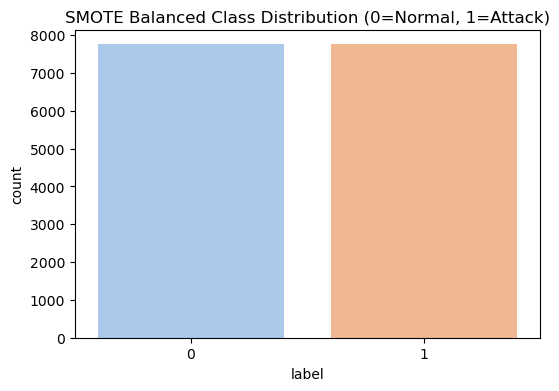

In [65]:
plt.figure(figsize=(6,4))
sns.countplot(x=y_train_smote, palette="pastel")
plt.title("SMOTE Balanced Class Distribution (0=Normal, 1=Attack)")
plt.show()


Training Logistic Regression...
Logistic Regression - Training Accuracy: 88.3733%
Training Classification Report:
               precision    recall  f1-score   support

      Normal       0.86      0.92      0.89      7758
      Attack       0.91      0.85      0.88      7758

    accuracy                           0.88     15516
   macro avg       0.89      0.88      0.88     15516
weighted avg       0.89      0.88      0.88     15516



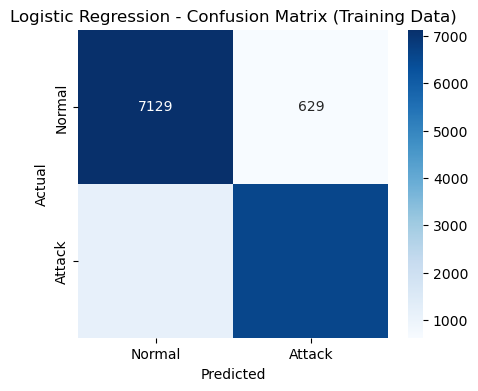

Logistic Regression - Test Accuracy: 84.9789%
Test Classification Report:
               precision    recall  f1-score   support

      Normal       0.55      0.93      0.69       430
      Attack       0.98      0.83      0.90      1940

    accuracy                           0.85      2370
   macro avg       0.77      0.88      0.80      2370
weighted avg       0.90      0.85      0.86      2370



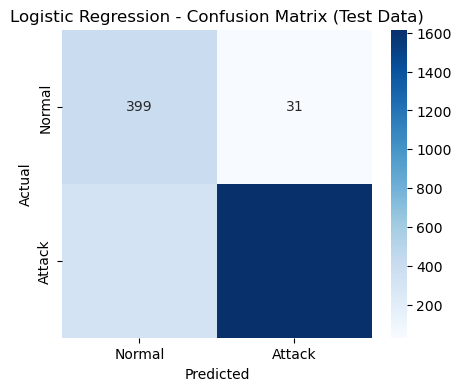


Training Random Forest...
Random Forest - Training Accuracy: 99.7615%
Training Classification Report:
               precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      7758
      Attack       1.00      1.00      1.00      7758

    accuracy                           1.00     15516
   macro avg       1.00      1.00      1.00     15516
weighted avg       1.00      1.00      1.00     15516



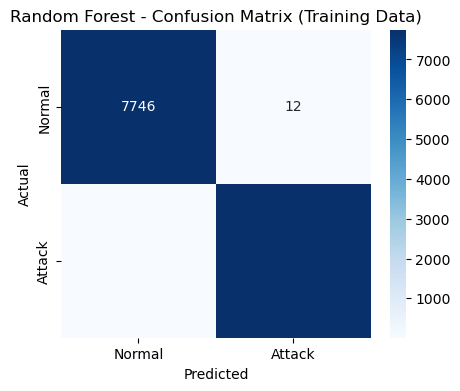

Random Forest - Test Accuracy: 97.7637%
Test Classification Report:
               precision    recall  f1-score   support

      Normal       0.94      0.94      0.94       430
      Attack       0.99      0.99      0.99      1940

    accuracy                           0.98      2370
   macro avg       0.96      0.96      0.96      2370
weighted avg       0.98      0.98      0.98      2370



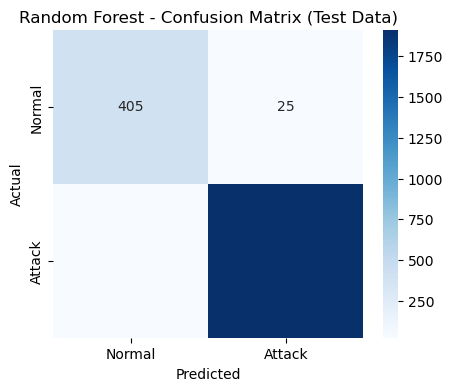


Training SVM...
SVM - Training Accuracy: 93.8386%
Training Classification Report:
               precision    recall  f1-score   support

      Normal       0.91      0.97      0.94      7758
      Attack       0.97      0.91      0.94      7758

    accuracy                           0.94     15516
   macro avg       0.94      0.94      0.94     15516
weighted avg       0.94      0.94      0.94     15516



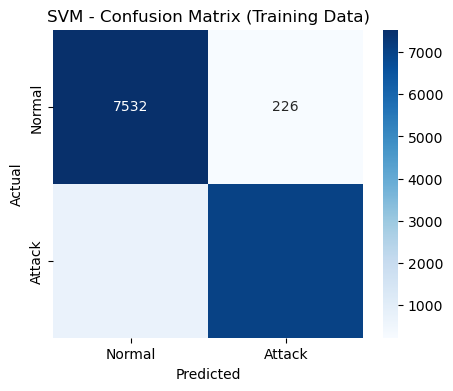

SVM - Test Accuracy: 90.2954%
Test Classification Report:
               precision    recall  f1-score   support

      Normal       0.66      0.96      0.78       430
      Attack       0.99      0.89      0.94      1940

    accuracy                           0.90      2370
   macro avg       0.83      0.93      0.86      2370
weighted avg       0.93      0.90      0.91      2370



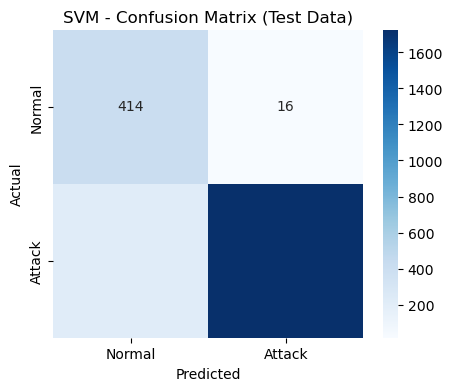

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Example ML Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(kernel='rbf', random_state=42)
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_smote, y_train_smote)  # Train on SMOTE-balanced data

    # Predictions on training data
    y_train_pred = model.predict(X_train_smote)
    train_acc = accuracy_score(y_train_smote, y_train_pred)
    train_report = classification_report(y_train_smote, y_train_pred, target_names=["Normal", "Attack"])
    train_cm = confusion_matrix(y_train_smote, y_train_pred)
    
    print(f"{name} - Training Accuracy: {train_acc*100:.4f}%")
    print("Training Classification Report:\n", train_report)
    
    plt.figure(figsize=(5,4))
    sns.heatmap(train_cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Normal", "Attack"],
                yticklabels=["Normal", "Attack"])
    plt.title(f"{name} - Confusion Matrix (Training Data)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # Predictions on test data
    y_test_pred = model.predict(X_test)
    test_acc = accuracy_score(y_test, y_test_pred)
    test_report = classification_report(y_test, y_test_pred, target_names=["Normal", "Attack"])
    test_cm = confusion_matrix(y_test, y_test_pred)
    
    print(f"{name} - Test Accuracy: {test_acc*100:.4f}%")
    print("Test Classification Report:\n", test_report)
    
    plt.figure(figsize=(5,4))
    sns.heatmap(test_cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Normal", "Attack"],
                yticklabels=["Normal", "Attack"])
    plt.title(f"{name} - Confusion Matrix (Test Data)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    
    # Store results
    results[name] = {
        "train_accuracy": train_acc,
        "train_classification_report": train_report,
        "train_confusion_matrix": train_cm,
        "test_accuracy": test_acc,
        "test_classification_report": test_report,
        "test_confusion_matrix": test_cm
    }
